# Imports #

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import math 

# Rational Bezier Function #

In [ ]:
def b_polynomial(t,P):
    n = len(P)-1
    num_x = np.zeros([n+1,len(t)])
    num_y = np.zeros([n+1,len(t)])
    denom = np.zeros([n+1, len(t)])

    for i in range(n+1):
        w = P[i][0]
        x = P[i][1]
        y = P[i][2]
        comb = math.comb(n,i)
        B_i = comb*(t**i)*(1-t)**(n-i)
        num_x[i,:]= B_i*w*x
        num_y[i,:]=B_i*w*y
        denom[i,:]=B_i*w
    B_x = np.sum(num_x,axis=0)
    B_y = np.sum(num_y,axis=0)
    B_denom = np.sum(denom, axis=0)
    return B_x/B_denom, B_y/B_denom 

# Function to create ECG signal #

In [1194]:
def ECG_wave(signal_type):
    #Checking signal type 
    if signal_type == 'Normal':
       points_preP = [[1,0,0],[1,0.5,0],[1,1,0],[1,1.5,0],[1,2,0],[1,2.5,0],[1,3,0]]
       points_P = [[1,3.4,0],[1.5,3.6,0.03],[1,3.8,0.12],[1,4,0.3],[1.5,5,0.9],[3,6,1.3],[1,7,0.8],[1,7.3,0.5],[1,7.6,0.16],[1.5,7.8,0.04],[1,8,0]]
       #points_P = [[5,3.5,0],[1,4,0.3],[2,5,0.9],[10,6,1.3],[2,7,0.8],[1.5,7.3,0.5],[5,8,0]]
       points_preQRS = [[1,8.25,0],[1,8.5,0],[1,8.75,0],[1,9,0],[1,9.25,0],[1,9.5,0],[1,10,0]]
       points_QRS = [[10,10,0],[10,10.2,0],[100,10.3,-0.05],[1,10.38,-0.2],[1,10.6,-0.65],[700,11.1,-1.5],[10,11.25,0],[1,11.4,2.5],[10,11.6,5.5],[1000,12,11],[10,12.35,5.5],[1,12.5,2.5],[1,12.65,0],[700,12.85,-3.3],[1,13.35,-1.5],[10,13.7,-0.1],[100,13.8,-0.03],[10,13.9,0]]
       #points_QRS = [[10,10.3,0],[500,11.1,-1.5],[10,11.25,0],[1000,12,11],[10,12.65,0],[500,12.85,-3.3],[10,13.7,0]]
       points_preT = [[1,14,0],[1,14.5,0],[1,14.75,0],[1,15,0],[1,15.5,0],[1,16,0],[1,16.5,0]]
       #points_T = [[5,17,0],[1,18,1],[2,19,1.9],[10,19.6,2.1],[2,21,0.55],[5,21.4,0]]
       points_T = [[1,16.9,0],[2,17.05,0.04],[1,17.2,0.1],[5,17,0],[1,18,1],[2,19,1.9],[10,19.6,2.1],[2,21,0.55],[1,21.2,0.15],[5,21.3,0.05],[1,21.42,0]]
       points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]
       
       prePx,prePy = b_polynomial(t,points_preP)
       Px,Py = b_polynomial(t,points_P)
       preQRSx,preQRSy = b_polynomial(t,points_preQRS)
       QRSx,QRSy = b_polynomial(t, points_QRS)
       preTx, preTy = b_polynomial(t, points_preT)
       Tx,Ty = b_polynomial(t, points_T)
       postTx, postTy = b_polynomial(t, points_postT)
       
       x = np.concatenate((prePx, Px, preQRSx,QRSx, preTx, Tx, postTx),axis=0)
       y = np.concatenate((prePy,Py,preQRSy, QRSy, preTy, Ty, postTy),axis=0)
 
    elif signal_type == "Ventricular pacing":
        points_preP = [[1,0,0],[1,1,0],[1,2,0],[1,2.5,0]]
        points_P = [[10,2.9,0],[5,3.6,0.7],[15,4.15,0.9],[15,4.25,0.9],[5,4.7,0.7],[10,5.4,0]]
        points_prePacemaker = [[1,5.5,0],[1,6,0],[1,7,0],[1,8,0]]
        points_Pacemaker = [[1,8.3,0],[10,8.4,14],[1,8.5,0]]
        points_QRS = [[2,9,-0.8],[1,9.5,-3.1],[5,9.9,-7.1],[5,10.2,-7.6],[1,10.5,-11.5],[10,11.05,-16.8],[1,11.5,-14.6],[1,12,-10.5],[1,12.5,-6.4],[1,13,-3],[10,13.6,0]]
        points_T = [[10,13.61,0],[1,13.8,0.4],[1,14,0.75],[1,14.5,1.8],[1,15,2.75],[1,15.5,3.6],[1,16,4.15],[5,16.5,4.75],[5,17,5.4],[15,17.45,5.7],[5,18,5.3],[5,18.5,4.4],[1,19,3],[1,19.5,1.6],[1,20,0.5],[1,20.4,0]]
        points_postT = [[1,21,0],[1,22,0],[1,23,0],[1,24,0],[1,25,0]]

        prePx,prePy = b_polynomial(t,points_preP)
        Px,Py = b_polynomial(t,points_P)
        prePacemakerx, prePacemakery = b_polynomial(t,points_prePacemaker)
        Pacemakerx, Pacemakery = b_polynomial(t,points_Pacemaker)
        QRSx,QRSy = b_polynomial(t, points_QRS)
        Tx,Ty = b_polynomial(t, points_T)
        postTx, postTy = b_polynomial(t, points_postT)

        x = np.concatenate((prePx, Px, prePacemakerx, Pacemakerx, QRSx, Tx, postTx),axis=0)
        y = np.concatenate((prePy,Py,prePacemakery, Pacemakery, QRSy, Ty, postTy),axis=0)

    elif signal_type == "Mobitz type II - no conduction":
        points_preP = [[1,0,0],[1,0.5,0],[1,1,0],[1,1.5,0],[1,2,0],[1,2.5,0],[1,3,0]]
        #points_preP = [[1, 0.0, 0], [1, 0.125, 0], [1, 0.25, 0], [1, 0.375, 0], [1, 0.5, 0], [1, 0.625, 0], [1, 0.75, 0]]
        points_P = [[1,3.4,0],[1.5,3.6,0.03],[1,3.8,0.12],[1,4,0.3],[1.5,5,0.9],[3,6,1.3],[1,7,0.8],[1,7.3,0.5],[1,7.6,0.16],[1.5,7.8,0.04],[1,8,0]]
        #points_P = [[1, 0.85, 0], [1.5, 0.9, 0.03], [1, 0.95, 0.12], [1, 1.0, 0.3], [1.5, 1.25, 0.9], [3, 1.5, 1.3], [1, 1.75, 0.8], [1, 1.825, 0.5], [1, 1.9, 0.16], [1.5, 1.95, 0.04], [1, 2.0, 0]]
        points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]
        #points_postT = [[1, 5.375, 0], [1, 5.5, 0], [1, 5.625, 0], [1, 5.75, 0], [1, 5.875, 0], [1, 6.0, 0]]

       
        prePx,prePy = b_polynomial(t,points_preP)
        Px,Py = b_polynomial(t,points_P)
        # preQRSx,preQRSy = b_polynomial(t,points_preQRS)
        # QRSx,QRSy = b_polynomial(t, points_QRS)
        # preTx, preTy = b_polynomial(t, points_preT)
        # Tx,Ty = b_polynomial(t, points_T)
        postTx, postTy = b_polynomial(t, points_postT)
       
        x = np.concatenate((prePx, Px, postTx),axis=0)
        y = np.concatenate((prePy,Py,postTy),axis=0)

    elif signal_type == 'Slow conduction':
        points_preP = [[1,0,0],[1,0.5,0],[1,1,0],[1,1.5,0],[1,2,0],[1,2.5,0],[1,3,0]]
        points_P = [[1,3.4,0],[1.5,3.6,0.03],[1,3.8,0.12],[1,4,0.3],[1.5,5,0.9],[3,6,1.3],[1,7,0.8],[1,7.3,0.5],[1,7.6,0.16],[1.5,7.8,0.04],[1,8,0]]
        points_preQRS = [[1,8.25,0],[1,8.5,0],[1,8.75,0],[1,9,0],[1,9.25,0],[1,9.5,0],[1,10,0]]
        #points_QRS = [[10,10,0],[10,10.2,0],[100,10.3,-0.05],[1,10.38,-0.2],[1,10.6,-0.65],[700,11.1,-1.5],[10,11.25,0],[1,11.4,2.5],[10,11.6,5.5],[1000,12,11],[10,12.35,5.5],[1,12.5,2.5],[1,12.65,0],[700,12.85,-3.3],[1,13.35,-1.5],[10,13.7,-0.1],[100,13.8,-0.03],[10,13.9,0]]
        points_QRS = [[10,17,0],[10,17.2,0],[100,17.3,-0.05],[1,17.38,-0.2],[1,17.6,-0.65],[700,18.1,-1.5],[10,18.25,0],[1,18.4,2.5],[10,18.6,5.5],[1000,19,11],[10,19.35,5.5],[1,19.5,2.5],[1,19.65,0],[700,19.85,-3.3],[1,20.35,-1.5],[10,20.7,-0.1],[100,20.8,-0.03],[10,20.9,0]]
        #points_preT = [[1,14,0],[1,14.5,0],[1,14.75,0],[1,15,0],[1,15.5,0],[1,16,0],[1,16.5,0]]
        points_preT = [[1,21,0],[1,21.5,0],[1,21.75,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0]]
        #points_T = [[1,16.9,0],[2,17.05,0.04],[1,17.2,0.1],[5,17,0],[1,18,1],[2,19,1.9],[10,19.6,2.1],[2,21,0.55],[1,21.2,0.15],[5,21.3,0.05],[1,21.42,0]]
        points_T = [[1,23.9,0],[2,24.05,0.04],[1,24.2,0.1],[5,24,0],[1,25,1],[2,26,1.9],[10,26.6,2.1],[2,28,0.55],[1,28.2,0.15],[5,28.3,0.05],[1,28.42,0]]
        #points_postT = [[1,21.5,0],[1,22,0],[1,22.5,0],[1,23,0],[1,23.5,0],[1,24,0]]
        points_postT = [[1,28.5,0],[1,29,0],[1,29.5,0],[1,30,0],[1,30.5,0],[1,31,0]]

       
        prePx,prePy = b_polynomial(t,points_preP)
        Px,Py = b_polynomial(t,points_P)
        preQRSx,preQRSy = b_polynomial(t,points_preQRS)
        QRSx,QRSy = b_polynomial(t, points_QRS)
        preTx, preTy = b_polynomial(t, points_preT)
        Tx,Ty = b_polynomial(t, points_T)
        postTx, postTy = b_polynomial(t, points_postT)
       
        x = np.concatenate((prePx, Px, preQRSx,QRSx, preTx, Tx, postTx),axis=0)
        y = np.concatenate((prePy,Py,preQRSy, QRSy, preTy, Ty, postTy),axis=0)


    return x,y


# Patient heart rate function #
Used to get the spacing between pulses to achieve a certain patient heart rate

In [799]:
def heart_rate(patient_HR):
    '''
    Calculates the gap between beats based on patient heart rate in bpm
    Note: assumes all heart beats are exactly the same (based on standard heartbeat defined in ECG_wave function)
    only gives give that results in approximately patient_HR
    '''
    gap = (1500)*(0.04)/patient_HR - 0.4007574025940901 - 0.39924259740590995
    return gap



# Stitch beats function #
Puts heart beats in sequential order and determines whether next beat should be paced based on sensitivity and rate settings of pacemaker

In [ ]:
def stitch_beats_new(ecg_func, gap, regularity, sensitivity,rate, output, asynchronous,iterations=10):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type 
    gap: base gap between beats
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker in mV
    rate: programmed rate of pacemaker in bpm 
    output: output setting of pacemaker in mA
    asynchronous: boolean indicating if pacemaker is in asynchronous mode

    Returns:
    x: concatenated x values of ECG waveform for 10 iterations
    y: concatenated y values of ECG waveform for 10 iterations
    '''
 
    beat_list = ['Normal']
    offset = 0 
    time_since_sensed = 0 
    max_time_since_sensed = (1500*0.04)/rate
    capture_threshold = 1.5 
    if asynchronous:
        regularity = 'Regular' #Override regularity if asynchronous mode is on

    for i in range(iterations):
        #Will have to edit function so it checks sensitivity value at each iteration
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        #Only apply random scaling factor in x if regularity is 'Irregular', otherwise keep it constant
        if regularity == 'Irregular':
            scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
        else:
            scaling_factor_x = 0.8/(np.max(x_temp)-np.min(x_temp))
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))

        if offset == 0: #First beat in beat_list 
            R_location = 0
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x 
            y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Increase time since last sensed event if beat is not sensed
            if np.max(y_temp) < sensitivity:
                time_since_sensed += np.max(x_temp)
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Normal')
    
            
            #If beat is sensed, then determine location of R wave
            else:
                #Determine R wave location
                R_location = x_temp[np.argmax(y_temp)]
                 #Append normal heart beat - need to determine distance between R waves of subsequent beats to choose whether to pace
                if asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else:
                    beat_list.append('Normal')
                time_since_sensed = 0

            #Apply offset for next beat
            offset = np.max(x_temp)

            
           

        else: #Second beat onwards
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x
            y_temp = y_temp*scaling_factor_y

            #Determine gap based on regularity of heart rhythm
            if regularity == 'Irregular':
                gap += np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap

            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)

            if np.max(y_temp) < sensitivity: #Increase time since last sensed event if beat is not sensed
                time_since_sensed += np.max(x_temp) + gap
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Normal')

            else: #If beat is sensed, then determine location of R wave and calculate measured rate
                RR_dist = x_temp_shifted[np.argmax(y_temp)]-R_location
                #Convert distance between R waves to bpm
                measured_rate = 1500*0.04/RR_dist
                
                #Update R_location for next iteration
                if beat_list[i] == "Ventricular pacing":
                    R_location = x_temp_shifted[np.argmin(y_temp)] #R wave is at minimum for paced beat
                else:
                    R_location = x_temp_shifted[np.argmax(y_temp)] #R wave is at maximum for normal beat
                    
                if measured_rate < rate: #If the measured rate is less than the programmed rate, append a paced beat and then a normal beat
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    if not asynchronous:
                        beat_list.append("Normal") #I'm adding a normal beat after a paced beat, because I'm assuming the paced beat should have the correct heart rate
                
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: #Otherwise append a normal beat
                    beat_list.append('Normal')


    return x, y


In [ ]:
def stitch_beats_new(ecg_func, gap, regularity, sensitivity,rate, output, asynchronous,iterations=100):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type 
    gap: base gap between beats
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker in mV
    rate: programmed rate of pacemaker in bpm 
    output: output setting of pacemaker in mA
    asynchronous: boolean indicating if pacemaker is in asynchronous mode

    Returns:
    x: concatenated x values of ECG waveform for 10 iterations
    y: concatenated y values of ECG waveform for 10 iterations
    '''

    beat_list = ['Normal']
    offset = 0 
    time_since_sensed = 0 
    max_time_since_sensed = 60/rate 
    capture_threshold = 1.5 
    if asynchronous:
        regularity = 'Regular' #Override regularity if asynchronous mode is on

    for i in range(iterations):
        #Will have to edit function so it checks sensitivity value at each iteration
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        #Only apply random scaling factor in x if regularity is 'Irregular', otherwise keep it constant
        if regularity == 'Irregular':
            scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
        else:
            scaling_factor_x = 0.8/(np.max(x_temp)-np.min(x_temp))
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))

        if offset == 0: #First beat in beat_list 
            R_location = 0
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x 
            y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Increase time since last sensed event if beat is not sensed
            if np.max(y_temp) < sensitivity:
                time_since_sensed += np.max(x_temp)
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Normal')
    
            
            #If beat is sensed, then determine location of R wave
            else:
                #Determine R wave location
                R_location = x_temp[np.argmax(y_temp)]
                 #Append normal heart beat - need to determine distance between R waves of subsequent beats to choose whether to pace
                if asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else:
                    beat_list.append('Normal')
                time_since_sensed = 0

            #Apply offset for next beat
            offset = np.max(x_temp)

            
           

        else: #Second beat onwards
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x
            y_temp = y_temp*scaling_factor_y

            #Determine gap based on regularity of heart rhythm
            if regularity == 'Irregular':
                gap += np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap

            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)

            if np.max(y_temp) < sensitivity: #Increase time since last sensed event if beat is not sensed
                time_since_sensed += np.max(x_temp) + gap
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Normal')

            else: #If beat is sensed, then determine location of R wave and calculate measured rate
                RR_dist = x_temp_shifted[np.argmax(y_temp)]-R_location
                #Convert distance between R waves to bpm
                measured_rate = 60/RR_dist
                
                #Update R_location for next iteration
                if beat_list[i] == "Ventricular pacing":
                    R_location = x_temp_shifted[np.argmin(y_temp)] #R wave is at minimum for paced beat
                else:
                    R_location = x_temp_shifted[np.argmax(y_temp)] #R wave is at maximum for normal beat
                    
                if measured_rate < rate: #If the measured rate is less than the programmed rate, append a paced beat and then a normal beat
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Normal") #If no capture, just append normal beat
                    if not asynchronous:
                        beat_list.append("Normal") #I'm adding a normal beat after a paced beat, because I'm assuming the paced beat should have the correct heart rate
                
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: #Otherwise append a normal beat
                    beat_list.append('Normal')


    return x, y


## Plotting ##

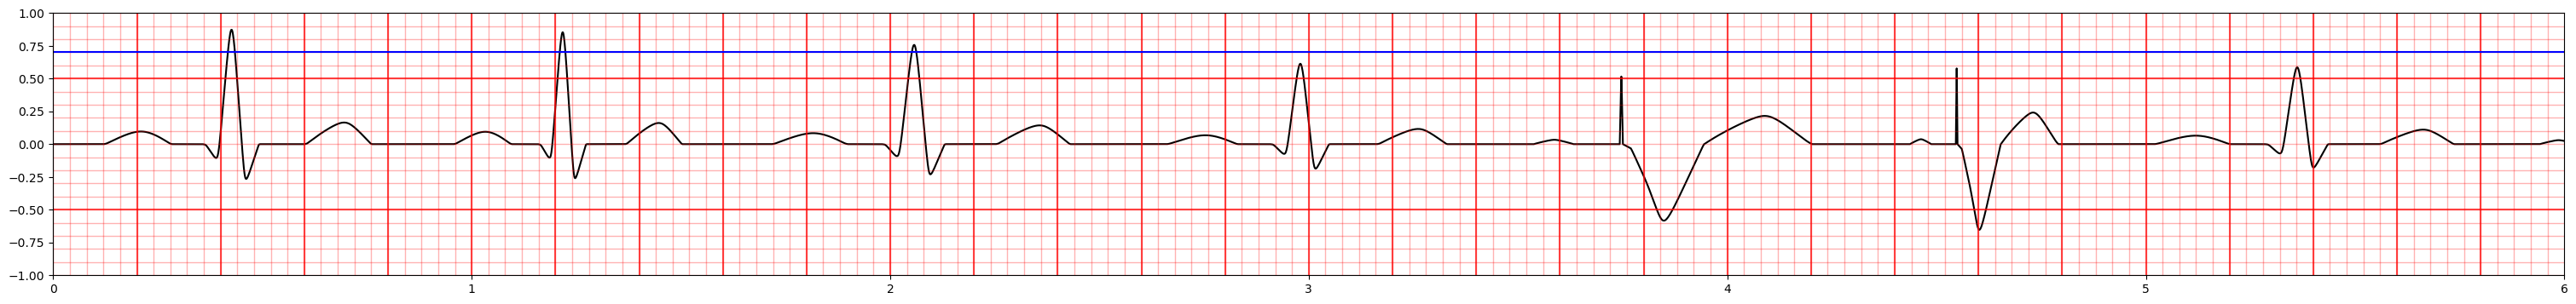

In [802]:
t = np.linspace(0,1,101)
patient_HR = 75
gap = heart_rate(patient_HR)
sensitivity = 0.7
x_ecg, y_ecg = stitch_beats_new(ECG_wave, gap, regularity='Irregular', sensitivity=sensitivity, rate=70, output=1.5, asynchronous=False)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_ecg, y_ecg, color='black')
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)

# 3rd Degree AV Block #

In [1168]:
def complete_AV_block(iterations,sensitivity,output,rate,patient_HR,asynchronous=False):
    # PP_interval = 3+np.random.random() #Constant PP interval - random each time
    # RR_interval = 5+np.random.random() #Constant RR interval - random each time
    RR_interval = 60/patient_HR
    PP_interval = RR_interval-0.3 + 0.04*np.random.random()-0.02 #Random PP interval from 0.58s to 0.62s

    storage = np.empty((3,iterations*2), dtype=object) #2D array to store P and R waves for each iteration of for loop. 1st row contains wave number, 2nd row contains x coordinates of trace, 3rd row contains y coordinates of trace
    max_vals = np.zeros([2,iterations*2]) #2D array to store max x value for each P and R wave for each iteration
    wave_num = 0 #Count to tell you which wave you're looking at 
    max_time_since_sensed = 60/rate  #Rate is rate set on pacemaker - not patient's intrinsic heartrate. When patient's ventricular rate falls below this value, paccemaker should pace
    capture_threshold = 1.5 
    time_since_sensed = 0 #Counts how long it's been since an R wave was sensed. If this is longer than the max time since sensed, pacemaker should pace



    #Points for 3rd deg AV block (normal)
    start = [[1,0,0]]
    points_P = [[1,2.45,0],[2,2.53,0.02],[1,2.6,0.12],[1,2.7,0.44],[2,2.8,0.65],[3,2.915,0.74],[2,3.05,0.63],[1,3.1,0.52],[1,3.2,0.16],[1,3.25,0.05],[2,3.3,0.01],[1,3.35,0]]
    points_R_first = [[1,4.4,0],[2,4.45,0.05],[1,4.5,0.15],[1,4.55,0.8],[5,4.625,1.2],[1,4.68,0.8],[1,4.7,0.4],[2,4.72,0]]
    points_R_second = [[2,4.72,0],[1,4.75,-1.2],[1,4.8,-2.6],[1,4.85,-3.6],[5,4.95,-4.4],[2,5.05,-4],[1,5.1,-3.8],[1,5.15,-3.6],[1,5.2,-3.2],[1,5.3,-3],[2,5.4,-2.6],[1,5.45,-2.2],[1,5.5,-1.2],[1,5.55,-0.6],[1,5.6,-0.2],[1,5.65,-0.1],[2,5.67,-0.05],[1,5.7,0]]
    points_R_third = [[1,5.7,0],[1,5.75,0.15],[1,5.8,0.25],[1,5.85,0.35],[1,5.9,0.44],[1,6,0.58],[1,6.1,0.77],[1,6.2,0.95],[1,6.3,1.15],[1,6.4,1.34],[2,6.5,1.58],[3,6.63,1.8],[2,6.7,1.75],[1,6.8,1.6],[1,6.9,1.3],[1,7,1],[1,7.1,0.6],[1,7.2,0.36],[1,7.3,0.15],[1,7.35,0.1],[2,7.4,0.03],[1,7.45,0]]


    #Points for ventricular pacing
    points_Pacemaker = [[1,2.656,0],[10,2.688,14],[1,2.72,0]]
    points_QRS = [[2,2.88,-0.8],[1,3.04,-3.1],[5,3.168,-7.1],[5,3.264,-7.6],[1,3.36,-11.5],[10,3.536,-16.8],[1,3.68,-14.6],[1,3.84,-10.5],[1,4.0,-6.4],[1,4.16,-3],[10,4.352,0]]
    points_T = [[10,4.3552,0],[1,4.416,0.4],[1,4.48,0.75],[1,4.64,1.8],[1,4.8,2.75],[1,4.96,3.6],[1,5.12,4.15],[5,5.28,4.75],[5,5.44,5.4],[15,5.584,5.7],[5,5.76,5.3],[5,5.92,4.4],[1,6.08,3],[1,6.24,1.6],[1,6.4,0.5],[1,6.528,0]]
    


    x = [] #List to store final trace in x
    y = [] #List to store final trace in y

    while wave_num < iterations*2:  #wave number is increased by 2 at each iteration 
        #Need diff scaling factors for P and R waves 
        #scaling_factor_x = 0.8/9.51 #Need to apply scaling factor in x before calculating time since sensed. Duration of normal heart beat is 80ms - divide by 9.51 (length of heart beat in x axis)
        #scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(1.5795239721682306+3.996635592950172)

        #Scaling factors 
        SF_x_R = 0.0393  
        SF_x_R *= 2
        SF_x_P = 0.0449
        SF_x_P *= 3
        SF_x_paced = 0.0413
        SF_x_paced *= 2
        SF_y_R = 0.295 + 0.06*np.random.random()-0.03
        SF_y_P = 0.1477 + 0.06*np.random.random()-0.03
        SF_y_paced = 0.05 + 0.006*np.random.random()-0.003
        SF_y_paced *= 1.333


        if wave_num == 0: #First beat
            #PR_dist = np.random.random()*4+1 #Random PR interval between 1 and 5. Only need to calculate for first iteration, for next iterations, determined by PP and RR intervals
            PR_dist = 0.5 + 0.04*np.random.random()-0.02 #Random PR interval between 0.28 and 0.32 seconds


            #Calculate traces
            start_x, start_y = b_polynomial(t, start)
            Px, Py = b_polynomial(t, points_P)
            R_firstx, R_firsty = b_polynomial(t, points_R_first)
            #R_firstx += PR_dist
            R_secondx, R_secondy = b_polynomial(t, points_R_second)
            #R_secondx += PR_dist
            R_thirdx, R_thirdy = b_polynomial(t, points_R_third)
            #R_thirdx += PR_dist
            R_wavex = np.concatenate((R_firstx,R_secondx,R_thirdx),axis=0)
            R_wavey = np.concatenate((R_firsty,R_secondy,R_thirdy),axis=0)

            #Apply scaling factors
            Py *= SF_y_P 
            Px *= SF_x_P
            R_wavey *= SF_y_R
            R_wavex *= SF_x_R
            R_wavex += PR_dist #Shift R wave by PR distance
            Px -= 0.2
            R_wavex -= 0.2


            storage[0,wave_num]= wave_num #Enter the current wave number in the first row of first column of the storage array
            storage[1,wave_num] = Px #Enter the x trace of the first P wave in the second row of the first column of the storage array
            storage[2,wave_num] = Py #Enter the y trace of the first P wave in the third row of the first column of the storage array
            max_vals[0,wave_num]= wave_num #Enter the current wave number in the first row of first column of the max_vals array
            max_vals[1,wave_num] = np.max(Px) #Enter the max value of the x trace of the first P wave in the second row of the first column of the storage array
            wave_num += 1 #Increase the wave number by 1
            storage[0,wave_num]= wave_num
            storage[1,wave_num] = R_wavex
            storage[2,wave_num] = R_wavey
            max_vals[0,wave_num]= wave_num
            max_vals[1,wave_num] = np.max(R_wavex)
            wave_num += 1


            offset_P = np.max(Px) + PP_interval
            offset_R = np.max(R_wavex) + RR_interval


            #First wave should never be paced 

            #Increase time since last sensed event if beat is not sensed
            if np.max(R_wavey) < sensitivity: #Only sensing R wave, not P wave
                time_since_sensed += np.max(R_wavex) #Increase time since sensed event

        else: #2nd beat onwards
            Px, Py = b_polynomial(t, points_P)
            #Px += offset_P
            

            R_firstx, R_firsty = b_polynomial(t, points_R_first)
            #R_firstx += offset_R
            R_secondx, R_secondy = b_polynomial(t, points_R_second)
            #R_secondx += offset_R
            R_thirdx, R_thirdy = b_polynomial(t, points_R_third)
            #R_thirdx += offset_R

            R_wavex = np.concatenate((R_firstx,R_secondx,R_thirdx),axis=0)
            R_wavey = np.concatenate((R_firsty,R_secondy,R_thirdy),axis=0)
            R_wavey *= SF_y_R
            R_wavex *= SF_x_R
            R_wavex += offset_R
            Px *= SF_x_P
            Px += offset_P
            Py *= SF_y_P

            offset_P = np.max(Px) + PP_interval

            #P wave comes before R or paced beat and isn't used for sensing 
            storage[0,wave_num]= wave_num
            storage[1,wave_num] = Px
            storage[2,wave_num] = Py
            max_vals[0,wave_num]= wave_num
            max_vals[1,wave_num] = np.max(Px)
            wave_num += 1
            

            #Need to integrate pacing logic at this point in the code 
            if asynchronous: #If in asynchronous mode, pace regardless of sensing
                if output >= capture_threshold:
                    pacemaker_x, pacemaker_y = b_polynomial(t,points_Pacemaker)
                    pacedQRS_x,pacedQRS_y = b_polynomial(t,points_QRS)
                    T_x,T_y = b_polynomial(t,points_T)

                    paced_x = np.concatenate((pacemaker_x,pacedQRS_x,T_x),axis=0)
                    paced_y = np.concatenate((pacemaker_y,pacedQRS_y,T_y),axis=0)

                    #paced_x *= 0.7 #Where does 0.7 come from?
                    # paced_x += offset_R + 0.2*SF_x_paced #Shift so starts at same place as R wave would be (replace junctional escape rhythym which is unreliable with reliable ventricular paced rhythym)
                    # paced_y /= 5.5
                    paced_y *= SF_y_paced
                    paced_x *= SF_x_paced
                    paced_x += offset_R + 0.2*SF_x_paced #Shift so starts at same place as R wave would be (replace junctional escape rhythym which is unreliable with reliable ventricular paced rhythym)


                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = paced_x
                    storage[2,wave_num] = paced_y
                    max_vals[0,wave_num]= wave_num
                    max_vals[1,wave_num] = np.max(paced_x) 
                    #print(f"Wave number: {wave_num}, paced beat")
                    wave_num += 1
                    offset_R = np.min(paced_x) + (np.max(paced_x)-np.min(paced_x))/2 + RR_interval 
                else: #If output too low, get normal R wave instead of paced beat
                    storage[1,wave_num] = R_wavex
                    storage[2,wave_num] = R_wavey
                    max_vals[0,wave_num]= wave_num
                    max_vals[1,wave_num] = np.max(R_wavex)
                    wave_num += 1
                    offset_R = np.min(R_wavex) + (np.max(R_wavex)-np.min(R_wavex))/2 + RR_interval
                    time_since_sensed = 0 #Even though didn't pace, bc sensed, should reset time since sensed

            elif time_since_sensed >= max_time_since_sensed: 
                if output >= capture_threshold:
                    pacemaker_x, pacemaker_y = b_polynomial(t,points_Pacemaker)
                    pacedQRS_x,pacedQRS_y = b_polynomial(t,points_QRS)
                    T_x,T_y = b_polynomial(t,points_T)

                    paced_x = np.concatenate((pacemaker_x,pacedQRS_x,T_x),axis=0)
                    paced_y = np.concatenate((pacemaker_y,pacedQRS_y,T_y),axis=0)

                    #paced_x *= 0.7 #Where does 0.7 come from?
                    # paced_x += offset_R + 0.2*SF_x_paced #Shift so starts at same place as R wave would be (replace junctional escape rhythym which is unreliable with reliable ventricular paced rhythym)
                    # paced_y /= 5.5
                    paced_y *= SF_y_paced
                    paced_x *= SF_x_paced
                    paced_x += offset_R + 0.2*SF_x_paced #Shift so starts at same place as R wave would be (replace junctional escape rhythym which is unreliable with reliable ventricular paced rhythym)


                    storage[0,wave_num] = wave_num
                    storage[1,wave_num] = paced_x
                    storage[2,wave_num] = paced_y
                    max_vals[0,wave_num]= wave_num
                    max_vals[1,wave_num] = np.max(paced_x) 
                    #print(f"Wave number: {wave_num}, paced beat")
                    wave_num += 1
                    offset_R = np.min(paced_x) + (np.max(paced_x)-np.min(paced_x))/2 + RR_interval #Add offset to centre of wave
                    time_since_sensed = 0 #Reset time since sensed after pacing
                else: #If output too low, get normal R wave instead of paced beat
                    storage[1,wave_num] = R_wavex
                    storage[2,wave_num] = R_wavey
                    max_vals[0,wave_num]= wave_num
                    max_vals[1,wave_num] = np.max(R_wavex)
                    wave_num += 1
                    offset_R = np.min(R_wavex) + (np.max(R_wavex)-np.min(R_wavex))/2 + RR_interval
                    time_since_sensed = 0 #Even though didn't pace, bc sensed, should reset time since sensed

            else: #If rate from junctional escape beats is sufficient, don't pace
                storage[1,wave_num] = R_wavex
                storage[2,wave_num] = R_wavey
                max_vals[0,wave_num]= wave_num
                max_vals[1,wave_num] = np.max(R_wavex)
                #print(f"Wave number: {wave_num}, should be paced, but settings wrong")
                wave_num += 1
                offset_R = np.min(R_wavex) + (np.max(R_wavex)-np.min(R_wavex))/2 + RR_interval

                #Increase time since last sensed event if beat is not sensed
                if np.max(R_wavey) < sensitivity:
                    time_since_sensed += np.max(R_wavex) #Increase time since sensed event




    #Putting waves in order and preventing overlapping waves from plotting on top of e/o
    sort_idx = np.argsort(max_vals[1, :]) #Array of indexes that sort the max x value row 
    max_vals_sorted = max_vals[:, sort_idx] #Reorder both rows using these indexes. Array now contains traces in order  
    x = np.concatenate((x, start_x),axis = 0) #Start making the x array by adding the points in start_x
    y = np.concatenate((y, start_y),axis=0) #Start making the y array by adding the points in start_y

    for i in range(wave_num):
        idx = max_vals_sorted[0,i] #Iterate through sorted array containing index of waves in order 
        idx = int(idx) #Convert index to integer 
        x_temp = storage[1,idx] #Take that specific x trace out of the storage array
        y_temp = storage[2,idx] #Take ordered y trace out of storage array 

        # #Calculate the scaling factor in x
        # if i == 1: #Second wave in array is R wave - taking max x position of this gives length of 1 full cycle
        #     scaling_factor_x = 0.8/9.51

        #Add wave for first index 
        if i == 0:
            x = np.concatenate((x,x_temp),axis=0)
            y = np.concatenate((y,y_temp),axis=0)
        
        #Check if overlap for subsequent waves 
        elif i > 0: 
            if np.min(x_temp) < np.max(x): #If there's overlap between R and P waves
                if np.max(y_temp) >= np.max(storage[2,idx-1]): #If new wave is R wave (max y value is bigger than max y value of previous wave), get rid of previous wave
                    cutoff = len(storage[1,idx-1]) #How much to cut off from array to get rid of P wave
                    x = x[:-cutoff] # get rid of old wave (P wave)
                    y = y[:-cutoff]
                    x = np.concatenate((x,x_temp),axis=0) #Add R wave
                    y = np.concatenate((y,y_temp),axis=0)
                #If new wave is P wave do nothing 
            else: #Otherwise, just add the new wave to the array 
                x = np.concatenate((x,x_temp),axis=0)
                y = np.concatenate((y,y_temp),axis=0)
    
    #scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(1.5795239721682306+3.996635592950172)
    # x *= scaling_factor_x
    # y *= scaling_factor_y


    return x, y

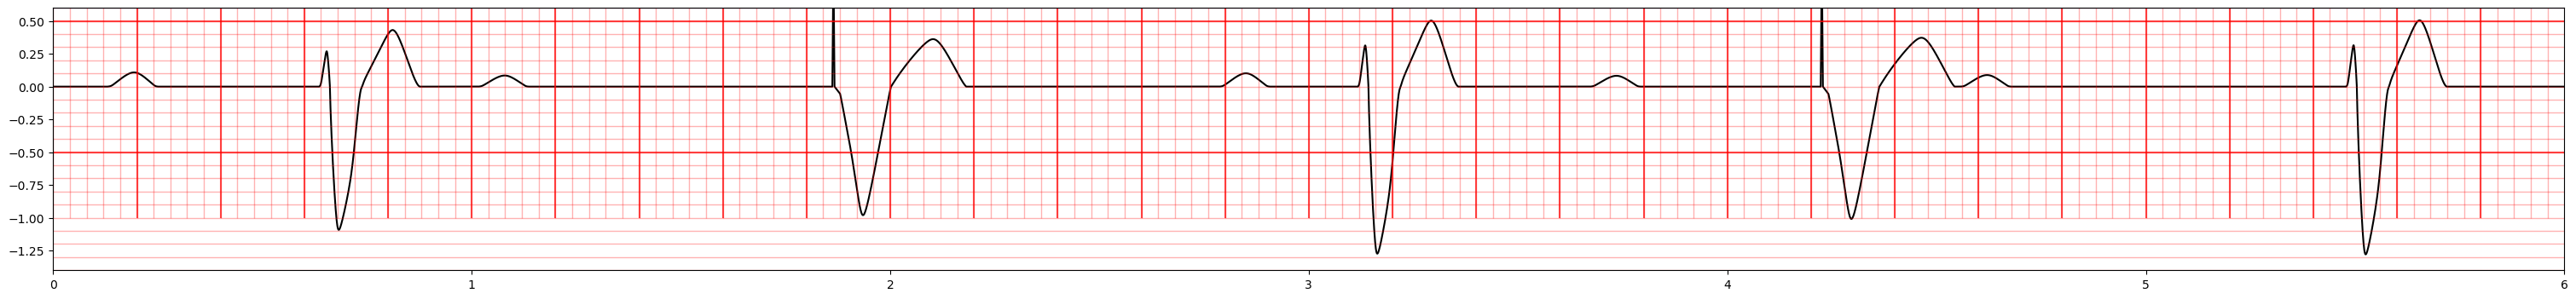

In [1172]:
t = np.linspace(0,1,101)
iterations = 100
sensitivity = 0.6
output = 1.6 
rate = 80
patient_HR = 80
x,y = complete_AV_block(iterations,sensitivity,output,rate,patient_HR,asynchronous=False)


fig2, ax2 = plt.subplots(figsize=(38, 4))
ax2.plot(x,y, color='black')
ax2.set_xlim(0,8)

ax2.set_xlim(0, 6)
ax2.set_ylim(-1.4, 0.6)

# compute line positions 
big_lines_v = np.arange(0, 8, 0.2)
small_lines_v = np.arange(0, 8, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax2.get_ylim()
xmin, xmax = ax2.get_xlim()

# # draw vertical lines (from ymin to ymax) in a single call each
# ax2.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
# ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# # draw horizontal lines (from xmin to xmax)
# ax2.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
# ax2.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)


# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax2.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax2.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax2.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax2.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)


#Line to indicate sensitivity setting
ax2.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)


# Mobitz Type II #


In [1173]:
def Mobitz_type_II(ecg_func, gap, regularity, sensitivity,rate, output, asynchronous,iterations=100):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type 
    gap: base gap between beats
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker in mV
    rate: programmed rate of pacemaker in bpm 
    output: output setting of pacemaker in mA
    asynchronous: boolean indicating if pacemaker is in asynchronous mode

    Returns:
    x: concatenated x values of ECG waveform for 10 iterations
    y: concatenated y values of ECG waveform for 10 iterations
    '''
    #Need to add async option 
    #Maybe can add something so points in ECG wave function randomised 
    beat_list = ['Normal']
    offset = 0 
    time_since_sensed = 0 
    max_time_since_sensed = 60/rate 
    capture_threshold = 1.5 
    prob_conduction = 0.8
    if asynchronous:
        regularity = 'Regular' #Override regularity if asynchronous mode is on

    for i in range(iterations):
        rand_num = np.random.rand()
        #Will have to edit function so it checks sensitivity value at each iteration
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        #Only apply random scaling factor in x if regularity is 'Irregular', otherwise keep it constant
        
        if regularity == 'Irregular':
            scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
        else:
            scaling_factor_x = 0.8/(np.max(x_temp)-np.min(x_temp))
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))
        scaling_factor_y_heartblock = scaling_factor_y*0.08
        scaling_factor_x_heartblock = scaling_factor_x


        # print(f'Max in y is {np.max(y_temp)}, Min in y is {np.min(y_temp)}')
        # print(f'Max in x is {np.max(x_temp)}, Min in x is {np.min(x_temp)}')

        if offset == 0: #First beat in beat_list 
            R_location = 0
            #Apply scaling factors:
            if beat_list[i]=="Mobitz type II - no conduction":
                y_temp*= scaling_factor_y_heartblock
                x_temp*= scaling_factor_x_heartblock
            else:
                x_temp = x_temp*scaling_factor_x 
                y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Increase time since last sensed event if beat is not sensed
            if np.max(y_temp) < sensitivity:
                time_since_sensed += np.max(x_temp)
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    #THIS IS WRONG LOGIC - FIX
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        if rand_num <= prob_conduction: #80% chance of conduction 
                            beat_list.append("Normal") #If no capture, just append normal beat
                        else:
                            beat_list.append("Mobitz type II - no conduction")
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else: 
                    if rand_num <= prob_conduction:
                        beat_list.append('Normal')
                    else:
                        beat_list.append("Mobitz type II - no conduction")
    
            
            #If beat is sensed, then determine location of R wave
            else:
                #Determine R wave location
                R_location = x_temp[np.argmax(y_temp)]
                 #Append normal heart beat - need to determine distance between R waves of subsequent beats to choose whether to pace
                if asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else:
                    if rand_num <= prob_conduction:
                        beat_list.append('Normal')
                    else: 
                        beat_list.append("Mobitz type II - no conduction")
                time_since_sensed = 0

            #Apply offset for next beat
            offset = np.max(x_temp)

            
           

        else: #Second beat onwards
            #Apply scaling factors:
            if beat_list[i]=="Mobitz type II - no conduction":
                y_temp*= scaling_factor_y_heartblock
                x_temp*= scaling_factor_x_heartblock
            else:
                x_temp = x_temp*scaling_factor_x
                y_temp = y_temp*scaling_factor_y

            #Determine gap based on regularity of heart rhythm
            if regularity == 'Irregular':
                gap += np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap

            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)

            if np.max(y_temp) < sensitivity: #Increase time since last sensed event if beat is not sensed
                time_since_sensed += np.max(x_temp) + gap
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    else:
                        if rand_num <= prob_conduction:
                            beat_list.append("Normal") #If no capture, just append normal beat
                        else: 
                            beat_list.append("Mobitz type II - no conduction")
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: 
                    if rand_num <= prob_conduction:
                        beat_list.append('Normal')
                    else: 
                        beat_list.append("Mobitz type II - no conduction")

            else: #If beat is sensed, then determine location of R wave and calculate measured rate
                RR_dist = x_temp_shifted[np.argmax(y_temp)]-R_location
                #Convert distance between R waves to bpm
                measured_rate = 60/RR_dist
                
                #Update R_location for next iteration
                if beat_list[i] == "Ventricular pacing":
                    R_location = x_temp_shifted[np.argmin(y_temp)] #R wave is at minimum for paced beat
                else:
                    R_location = x_temp_shifted[np.argmax(y_temp)] #R wave is at maximum for normal beat
                    
                if measured_rate < rate: #If the measured rate is less than the programmed rate, append a paced beat and then a normal beat
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        if rand_num <= prob_conduction:
                            beat_list.append("Normal") #If no capture, just append normal beat
                        else: 
                            beat_list.append("Mobitz type II - no conduction")
                    if not asynchronous:
                        if prob_conduction <= 0.8:
                            beat_list.append("Normal") #I'm adding a normal beat after a paced beat, because I'm assuming the paced beat should have the correct heart rate
                        else: 
                            beat_list.append("Mobitz type II - no conduction")
                
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: #Otherwise append a normal beat
                    if rand_num <= prob_conduction:
                        beat_list.append('Normal')
                    else: 
                        beat_list.append("Mobitz type II - no conduction")


    return x, y


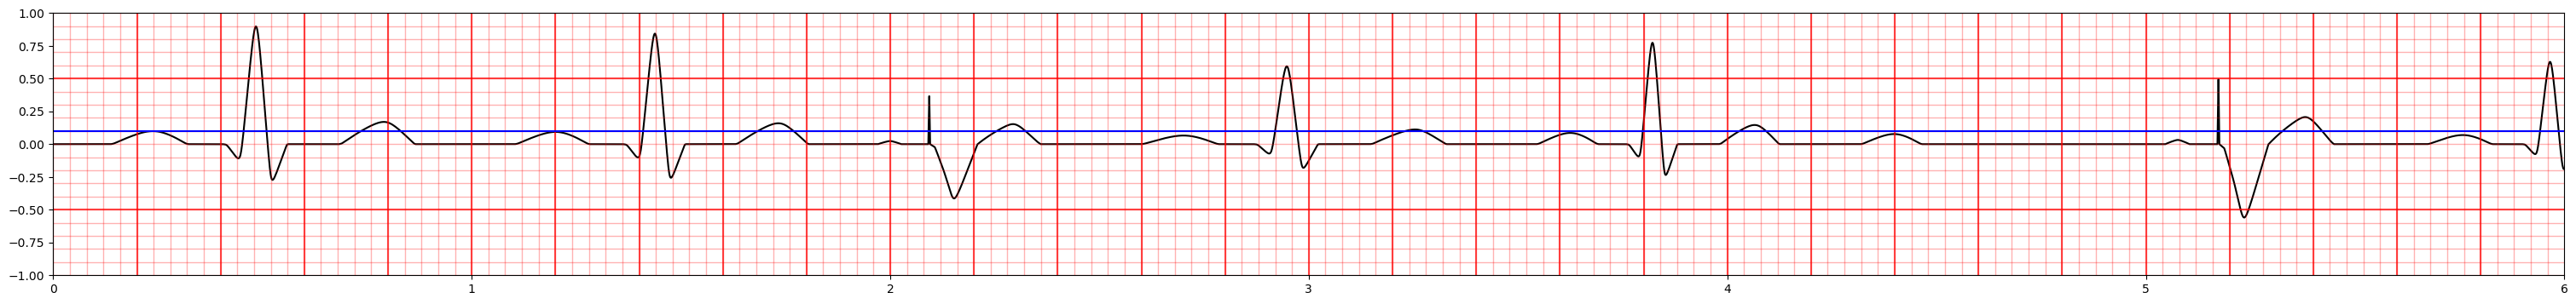

In [1174]:
t = np.linspace(0,1,101)
patient_HR = 75
gap = heart_rate(patient_HR)
sensitivity = 0.1
x_ecg, y_ecg = Mobitz_type_II(ECG_wave, gap, regularity='Irregular', sensitivity=sensitivity, rate=70, output=1.5, asynchronous=False)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_ecg, y_ecg, color='black')
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)

# Sick Sinus Syndrome #

# Slow Conduction #

In [1197]:
def slow_conduction(ecg_func, gap, regularity, sensitivity,rate, output, asynchronous,iterations=100):
    ''' Function to stitch together multiple ECG beats into a continuous signal.
    Parameters:
    ecg_func: function that generates ECG waveform for a given signal type 
    gap: base gap between beats
    regularity: 'Regular' or 'Irregular' spacing between beats
    sensitivity: sensitivity setting of pacemaker in mV
    rate: programmed rate of pacemaker in bpm 
    output: output setting of pacemaker in mA
    asynchronous: boolean indicating if pacemaker is in asynchronous mode

    Returns:
    x: concatenated x values of ECG waveform for 10 iterations
    y: concatenated y values of ECG waveform for 10 iterations
    '''

    beat_list = ['Slow conduction']
    offset = 0 
    time_since_sensed = 0 
    max_time_since_sensed = 60/rate 
    capture_threshold = 1.5 
    if asynchronous:
        regularity = 'Regular' #Override regularity if asynchronous mode is on

    for i in range(iterations):
        #Will have to edit function so it checks sensitivity value at each iteration
        x_temp, y_temp = ecg_func(beat_list[i])
        
        #Make random scaling factor in x and y for each iteration so the pulses aren't exactly the same
        #Only apply random scaling factor in x if regularity is 'Irregular', otherwise keep it constant
        if regularity == 'Irregular':
            #scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(np.max(x_temp)-np.min(x_temp))
            scaling_factor_x = (0.8+(np.random.random()*0.6-0.3))/(24+2.582287981996621)
        else:
            scaling_factor_x = 0.8/(24+2.582287981996621)
        scaling_factor_y = (1.0+(np.random.random()*0.6-0.3))/(np.max(y_temp)-np.min(y_temp))

        if offset == 0: #First beat in beat_list 
            R_location = 0
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x 
            y_temp = y_temp*scaling_factor_y
            x = x_temp
            y = y_temp

            #Increase time since last sensed event if beat is not sensed
            if np.max(y_temp) < sensitivity:
                time_since_sensed += np.max(x_temp)
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Slow conduction") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Slow conduction')
    
            
            #If beat is sensed, then determine location of R wave
            else:
                #Determine R wave location
                R_location = x_temp[np.argmax(y_temp)]
                 #Append normal heart beat - need to determine distance between R waves of subsequent beats to choose whether to pace
                if asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                    beat_list.append("Ventricular pacing")
                else:
                    beat_list.append('Slow conduction')
                time_since_sensed = 0

            #Apply offset for next beat
            offset = np.max(x_temp)

            
           

        else: #Second beat onwards
            #Apply scaling factors:
            x_temp = x_temp*scaling_factor_x
            y_temp = y_temp*scaling_factor_y

            #Determine gap based on regularity of heart rhythm
            if regularity == 'Irregular':
                gap += np.random.random()*gap
            x_temp_shifted = x_temp + offset + gap

            x = np.concatenate((x, x_temp_shifted), axis=0)
            y = np.concatenate((y, y_temp), axis=0)
            offset = np.max(x_temp_shifted)

            if np.max(y_temp) < sensitivity: #Increase time since last sensed event if beat is not sensed
                time_since_sensed += np.max(x_temp) + gap
                #If time since last sensed event exceeds max time, append a paced beat
                if time_since_sensed >= max_time_since_sensed:
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Slow conduction") #If no capture, just append normal beat
                    time_since_sensed = 0 #Reset time since sensed after pacing
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: 
                    beat_list.append('Slow conduction')

            else: #If beat is sensed, then determine location of R wave and calculate measured rate
                RR_dist = x_temp_shifted[np.argmax(y_temp)]-R_location
                #Convert distance between R waves to bpm
                measured_rate = 60/RR_dist
                
                #Update R_location for next iteration
                if beat_list[i] == "Ventricular pacing":
                    R_location = x_temp_shifted[np.argmin(y_temp)] #R wave is at minimum for paced beat
                else:
                    R_location = x_temp_shifted[np.argmax(y_temp)] #R wave is at maximum for normal beat
                    
                if measured_rate < rate: #If the measured rate is less than the programmed rate, append a paced beat and then a normal beat
                    if output >= capture_threshold: #Check if output setting is sufficient for capture
                        beat_list.append("Ventricular pacing")
                    elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                    else:
                        beat_list.append("Slow conduction") #If no capture, just append normal beat
                    if not asynchronous:
                        beat_list.append("Slow conduction") #I'm adding a normal beat after a paced beat, because I'm assuming the paced beat should have the correct heart rate
                
                elif asynchronous: #If in asynchronous mode, append paced beat regardless of sensing
                        beat_list.append("Ventricular pacing")
                else: #Otherwise append a normal beat
                    beat_list.append('Slow conduction')


    return x, y


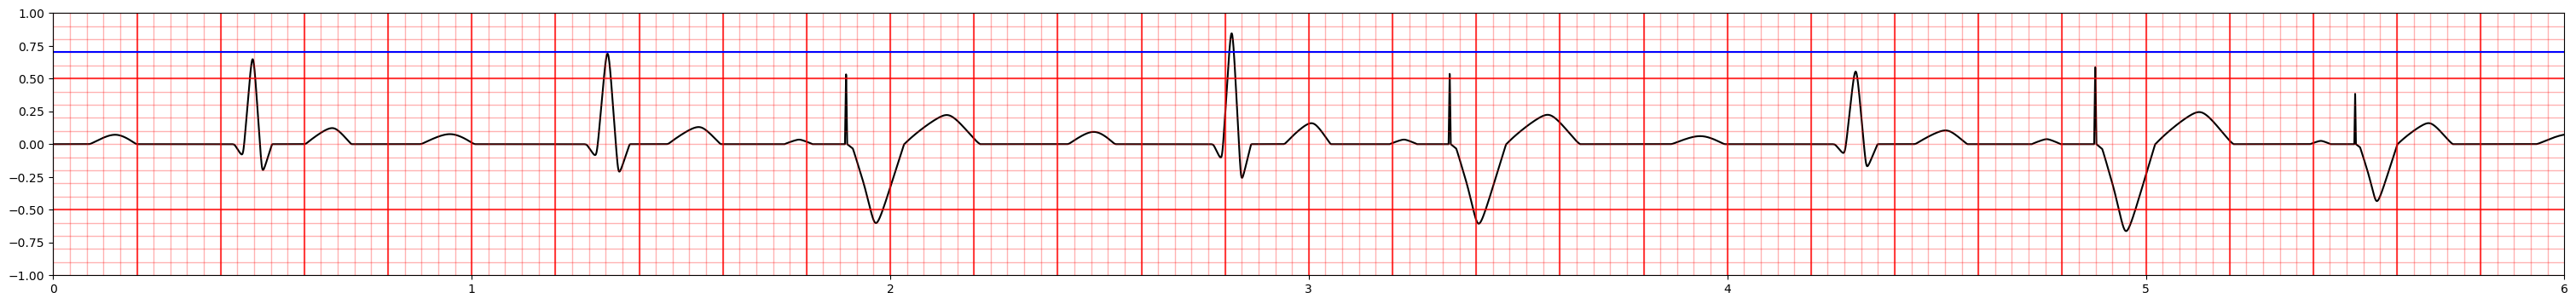

In [1198]:
t = np.linspace(0,1,101)
patient_HR = 75
gap = heart_rate(patient_HR)
sensitivity = 0.7
x_ecg, y_ecg = slow_conduction(ECG_wave, gap, regularity='Irregular', sensitivity=sensitivity, rate=70, output=1.5, asynchronous=False)

fig, ax = plt.subplots(figsize=(38, 4))
ax.plot(x_ecg, y_ecg, color='black')
ax.set_xlim(0, 6)
ax.set_ylim(-1, 1)

# compute line positions 
big_lines_v = np.arange(0, 6, 0.2)
small_lines_v = np.arange(0, 6, 0.04)
big_lines_h = np.arange(-1.5, 1.5, 1)
small_lines_h = np.arange(-1.5, 1.5, 0.1)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# draw vertical lines (from ymin to ymax) in a single call each
ax.vlines(big_lines_v, ymin, ymax, colors='red', alpha=0.7, linewidth=1.5)
ax.vlines(small_lines_v, ymin, ymax, colors='red', alpha=0.3, linewidth=1)

# draw horizontal lines (from xmin to xmax)
ax.hlines(big_lines_h, xmin, xmax, colors='red', alpha=0.7, linewidth=1.5)
ax.hlines(small_lines_h, xmin, xmax, colors='red', alpha=0.3, linewidth=1)

#Line to indicate sensitivity setting
ax.hlines(sensitivity, xmin, xmax, colors='blue', alpha=1, linewidth=1.5)